### 📌 **Light GBM(LGMB)이란?**

- 트리 기반의 학습 알고리즘인 gradient boosting 방식의 프레임워크

### 📌 **등장 배경**
기존에 있던 XGBoost의 부족한 점을 보완하기 위해 등장

- XGBoost: Gradient Boosting 방법론을 사용하여 Decision Tree로 학습을 진행하는 방법 중 하나. 과적합을 방지하고 병렬 학습이 가능하게 되는 등 최적화 과정이 들어간 Gradient Boosting Machine.

- GBDT(Gradient Boosting Decision Tree): Decision Tree를 만드는 과정에서 Gradient Boosting을 활용하는 방법
  - Boosting, Gradient와 같은 과정이 있으며 그 중에는 알고리즘의 종류를 결정하는 split 과정이 있다.

- Split 알고리즘
  1. Pre-Sort Algorithm
  2. **Histogram Based Algorithm**
    - 연속적인 변수 값을 이산적인 구간(bin)으로 나누고, 이 구간을 사용하여 학습과정 속에서 feature histogram을 구성
    - XGBoost에서는 이를 기반으로 한 HistGradientBoosting 방식 채택
👉 GBDT 과정에서 가장 많은 자원을 소모하는 것은 Split 과정이기 때문에 큰 데이터셋을 활용할 때에 `데이터셋의 크기(instance)`와 `feature의 개수`를 줄여야 함.

- 데이터셋의 크기(instance)를 줄이기 위한 방법 `Down Sampling`
  - 데이터 개체의 중요도(Weight)가 설정된 임계값을 넘지 못할 경우 데이터 개체들이 필터링 되는 방식
- feature의 개수를 줄이기 위한 방법: 약한 feature를 필터링

👉 XGB의 문제점을 보완하기 위한 LGBM의 구성
- 데이터셋의 크기를 줄이는 GOSS(Gradient-based One-Sided Sampling)
- feature의 개수를 줄이는 EFB(Exclusive Feature Bundling)

### 📌 **XGB와의 차이점**

| 기준 | XGB | LGBM |
| :--- | :--- | :--- |
| 트리 확장 구조 종류 | level-wise(수평 확장) | leaf-wise(수직 확장) |
| loss | 많음 | 적음 |
| 사용 가능한 데이터 용량 | 작음 | 큼 |
| 노드의 개수 | 많음(비효율적) | 적음(효율적) |
| 속도 | 느림 | 빠름 |
| 과적합 | 민감하지 않음 | 민감함(최소 10000개 이상의 데이터셋) |

+) Leaf-wise tree growth v.s. Level-wise tree growth

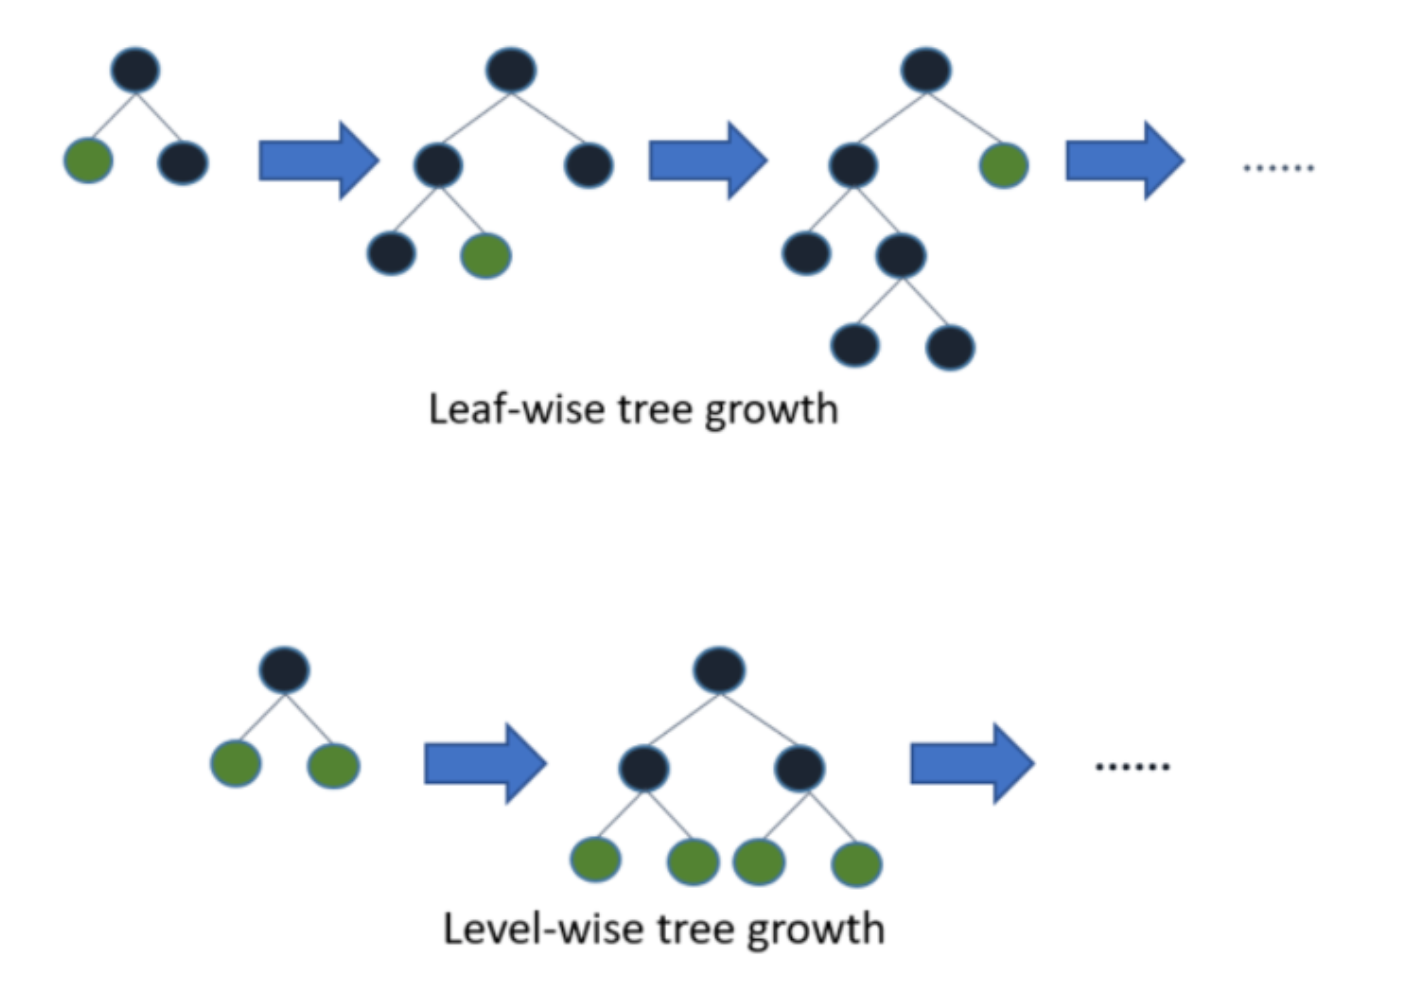

### 📌 **GOSS(Gradient-based One-Sided Sampling)**
- 데이터셋의 크기를 줄이는 알고리즘
  - 기본 가정: instance의 gradient가 클수록 영향력이 크고, 학습에 필요한 instance이다.

- Gradient가 큰 instance란
  - instance를 구성하는 element의 값의 변화가 클 수록 손실 함수에 변화가 크게 작용할 것이고, 이는 모델이 민감하게 반응하게 되므로 모델이 충분히 학습하지 못 한(학습에 필요한) instance로 분류
  👉 이러한 instance를 최대한 많이 포함하고 학습에 유의미하지 않은 instance는 제거한 데이터셋을 생성하는 것이 목표(데이터셋의 크기를 줄이며 정보는 최대한 보존)

- 알고리즘 단계
  1. 각 instance들의 gradient 계산 및 정렬
  2. gradient 상위 a × 100 만큼의 instance 선택
  3. 남은 instance들 중 b × 100 만큼을 무작위로 선택하고, 이 instance들에 상수 (1−a)/b를 곱합
      - 이 instacne들은 충분히 학습이 되었으나, 데이터셋의 분포를 위해 일부분을 포함시키며 (1−a)/b는 트리 split 과정에서 information gain을 계산할 시 가중치를 곱해주는 역할 수행
  4. 선택한 instance들로 GBDT 생성

### 📌 **EFB(ExclusiveFeature Bumdling)**
- 데이터셋의 feature 개수를 줄이는 알고리즘
  - 기본 가정: 고차원의 데이터가 sparse(일부 feature에만 값이 존재하며 대부분의 feature는 null 혹은 0이 채워졌다)하다는 가정 하에 상호배타적인 변수들을 하나의 bucket으로 묶어 feature들의 오류를 줄이는 방식

- EFB가 수행하는 2가지 절차
  1. greedy bundling: 현재 존재하는 feature 세트들에 대해서 어떠한 feature들을 하나의 번들로 묶을 것인지 결정
    - 이때 그래프를 그려 확인하며 node는 feature, edge는 두 feature들 간의 conflict(상호배타적이지 않은)로 정의. 이때, conflict가 많은 경우 중복이 많아 번들로 묶으면 안 됨
  2. merge exclusive features: 실질적으로 번들링이 되어야 하는 feature들을 이용하여 하나의 변수로 값을 표현하는 과정
  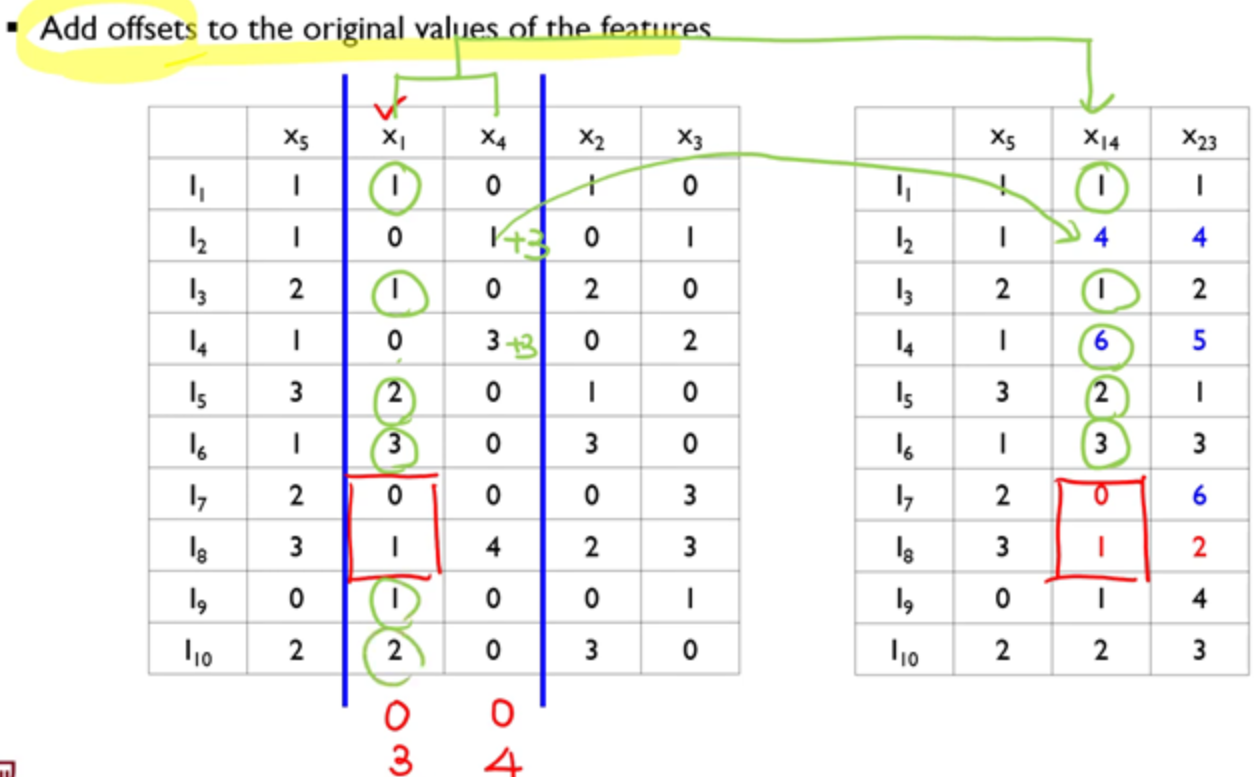
    - x1이 기준이라고 했을 때,
      - x1에만 값이 존재할 때, x1과 x4 모두 값이 존재할 때: 새 feature에 x1의 값을 대입
      - x4에만 값이 존재할 때: 새 feature에 x4 + x1의 최댓값(그림에서는 3)을 대입
    
👉 상호 배타적인/서로 상관계수가 낮은 feature들을 그룹화하여 feature 개수를 줄임

### 📌 **파라미터 정리**

1. 핵심 제어 파라미터 (Core Parameters)

| 파라미터 | 기본값 | 설명 |
| --- | --- | --- |
| `max_depth` | 1 | Tree의 최대 깊이를 뜻하며, 모델 **과적합(Overfitting)**을 방지할 때 사용. |
| `num_leaves` | 31 | 하나의 트리가 가질 수 있는 **최대 리프 개수**. 모델 복잡도를 결정하는 핵심 지표. |
| `min_data_in_leaf` | 20 | 리프 노드가 가져야 할 최소 레코드 수. 과적합 제어 시 사용. |
| `learning_rate` | 0.1 | 각 트리가 결과에 미치는 영향력을 조절하며, 업데이트 변화의 크기를 컨트롤. |
| `num_iterations` | 100 | 반복 수행하려는 **트리의 총 개수**. |

2. 학습 설정 파라미터 (Training Parameters)

| 파라미터 | 기본값 | 설명 |
| --- | --- | --- |
| `Task` | train | 수행할 임무 정의. (훈련: `train`, 예측: `predict`) |
| `application` | regression | 모델의 애플리케이션 타입 정의. (`regression`, `binary`, `multiclass`) |
| `objective` | regression | 목적 함수 설정. (수치 예측: `regression`, 이진 분류: `binary`) |
| `boosting` | gdbt | 알고리즘 타입을 정의. (`gdbt`, `rf`, `dart`, `goss`) |
| `metric` | "" | 성능 평가 지표를 설정. (`rmse`, `binary_logloss`, `multi_logloss` 등) |

3. 과적합 방지 및 성능 최적화 (Regularization & Efficiency)

| 파라미터 | 기본값 | 설명 |
| --- | --- | --- |
| `feature_fraction` | 1.0 | 개별 트리 학습 시 무작위로 선택하는 feature(변수)의 비율. |
| `bagging_fraction` | 1.0 | 데이터 샘플링 비율을 뜻하며 과적합 제어에 도움. |
| `early_stopping_round` | 0 | 설정한 라운드 동안 지표가 향상되지 않으면 학습을 중단하여 속도 향상. |
| `lambda_l1` | 0.0 | **L1 규제**를 통한 가중치를 제어. |
| `lambda_l2` | 0.0 | **L2 규제**를 통한 가중치를 제어. |
| `max_cat_group` | 64 | 카테고리 그룹의 분기 포인트를 찾기 위해 그룹화하는 최대 개수. |
| `scale_pos_weight` | 1 | 불균형 데이터에서 **양성(Positive) 레이블에 가중치** 부여. |

### 📌 **예제**

- classification

```python
from lightgbm import LGBMClassifier

model = LGBMClassifier() # all hyper-parameter : default
model.fit(X_train, y_train)

# Prediction
print('Train Score : {}'.format(model.score(X_train, y_train)))
print('Test Score : {}'.format(model.score(X_test,y_test)))
```


- Regression

```python
from lightgbm import LGBMRegressor
model = LGBMRegressor() # all hyper-parameter : default
model.fit(X_train, y_train)

# Prediction
print('Train Score : {}'.format(model.score(X_train, y_train)))
print('Test Score : {}'.format(model.score(X_test,y_test)))
```

### 📌 **하이퍼 파라미터 튜닝 방법**
1. grid search: 모든 가능한 조합을 격자(Grid)처럼 하나씩 다 시도해 보는 방식
  - 설정한 범위 내에서 가장 좋은 조합을 확실히 찾을 수 있지만, 파라미터가 많아지면 시간이 매우 오래 소요됨
  - 튜닝할 파라미터가 적고, 확실한 최적점을 찾고 싶을 때 적합

2. random search: 정해진 범위 내에서 무작위(Random)로 조합을 골라 테스트하는 방식
  - 그리드 서치보다 훨씬 빠르며, 상대적으로 적은 시도만으로도 꽤 괜찮은 성능의 파라미터 발견
  - 파라미터 종류가 많거나, 리소스(시간, 컴퓨터 성능)가 제한적일 때 적합

3. bayesian optimization: 이전 시도의 결과를 바탕으로 어느 영역이 더 좋을지 확률적으로 예측하며 찾아가는 방식
  - Optuna나 Hyperopt 같은 라이브러리를 주로 사용, 효율이 매우 좋음
  - 대규모 데이터셋이나 딥러닝, LightGBM처럼 파라미터가 복잡한 모델을 다룰 때 적합

👉 Optuna는 시각화 도구를 제공하기 때문에 모델 성능에 영향을 많이 미치는 파라미터를 확인하기 용이